# LangGraph and LangSmith - Agentic RAG Powered by LangChain

In the following notebook we'll complete the following tasks:

- 🤝 Breakout Room #1:
  1. Install required libraries
  2. Set Environment Variables
  3. Creating our Tool Belt
  4. Creating Our State
  5. Creating and Compiling A Graph!

- 🤝 Breakout Room #2:
  1. Evaluating the LangGraph Application with LangSmith
  2. Adding Helpfulness Check and "Loop" Limits
  3. LangGraph for the "Patterns" of GenAI

# 🤝 Breakout Room #1

## Part 1: LangGraph - Building Cyclic Applications with LangChain

LangGraph is a tool that leverages LangChain Expression Language to build coordinated multi-actor and stateful applications that includes cyclic behaviour.

### Why Cycles?

In essence, we can think of a cycle in our graph as a more robust and customizable loop. It allows us to keep our application agent-forward while still giving the powerful functionality of traditional loops.

Due to the inclusion of cycles over loops, we can also compose rather complex flows through our graph in a much more readable and natural fashion. Effectively allowing us to recreate application flowcharts in code in an almost 1-to-1 fashion.

### Why LangGraph?

Beyond the agent-forward approach - we can easily compose and combine traditional "DAG" (directed acyclic graph) chains with powerful cyclic behaviour due to the tight integration with LCEL. This means it's a natural extension to LangChain's core offerings!

## Task 1:  Dependencies


## Task 2: Environment Variables

We'll want to set our OpenAI, Tavily, and LangSmith API keys along with our LangSmith environment variables.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
# import getpass

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY") #getpass.getpass("OpenAI API Key:")

In [2]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY") #getpass.getpass("TAVILY_API_KEY")

In [3]:
from uuid import uuid4

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE8 - LangGraph - {uuid4().hex[0:8]}"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY") #getpass.getpass("LangSmith API Key: ")

## Task 3: Creating our Tool Belt

As is usually the case, we'll want to equip our agent with a toolbelt to help answer questions and add external knowledge.

There's a tonne of tools in the [LangChain Community Repo](https://github.com/langchain-ai/langchain-community/tree/main/libs/community) but we'll stick to a couple just so we can observe the cyclic nature of LangGraph in action!

We'll leverage:

- [Tavily Search Results](https://github.com/langchain-ai/langchain-community/blob/main/libs/community/langchain_community/tools/tavily_search/tool.py)
- [Arxiv](https://github.com/langchain-ai/langchain-community/blob/main/libs/community/langchain_community/tools/arxiv/tool.py)

#### 🏗️ Activity #1:

Please add the tools to use into our toolbelt.

> NOTE: Each tool in our toolbelt should be a method.

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun

tavily_tool = TavilySearchResults(max_results=5)

tool_belt = [
    tavily_tool,
    ArxivQueryRun(),
]

/var/folders/tb/tknsg8m10jvc1t4fztzvf7kh0000gn/T/ipykernel_59359/1203815797.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


### Model

Now we can set-up our model! We'll leverage the familiar OpenAI model suite for this example - but it's not *necessary* to use with LangGraph. LangGraph supports all models - though you might not find success with smaller models - as such, they recommend you stick with:

- OpenAI's GPT-3.5 and GPT-4
- Anthropic's Claude
- Google's Gemini

> NOTE: Because we're leveraging the OpenAI function calling API - we'll need to use OpenAI *for this specific example* (or any other service that exposes an OpenAI-style function calling API.

In [5]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4.1-nano", temperature=0)

Now that we have our model set-up, let's "put on the tool belt", which is to say: We'll bind our LangChain formatted tools to the model in an OpenAI function calling format.

In [6]:
model = model.bind_tools(tool_belt)

#### ❓ Question #1:

How does the model determine which tool to use?
##### ✅ Answer: The model uses the tool classes built-in description. It understands the user's intent in the query, and uses the tool's built-in description or user provided description to infer which tool to call. It may also use the schema, i.e., the parameter names and types to provide context. The tool name could also be used to infer its purpose. For example, a user query could be 'Find recent papers on Machine Learning'. The model can infer that the word 'recent' suggests current information, and TavilySearch (web search) would be better for recent news, while Arxiv would be better for academic papers.

## Task 4: Putting the State in Stateful

Earlier we used this phrasing:

`coordinated multi-actor and stateful applications`

So what does that "stateful" mean?

To put it simply - we want to have some kind of object which we can pass around our application that holds information about what the current situation (state) is. Since our system will be constructed of many parts moving in a coordinated fashion - we want to be able to ensure we have some commonly understood idea of that state.

LangGraph leverages a `StatefulGraph` which uses an `AgentState` object to pass information between the various nodes of the graph.

There are more options than what we'll see below - but this `AgentState` object is one that is stored in a `TypedDict` with the key `messages` and the value is a `Sequence` of `BaseMessages` that will be appended to whenever the state changes.

Let's think about a simple example to help understand exactly what this means (we'll simplify a great deal to try and clearly communicate what state is doing):

1. We initialize our state object:
  - `{"messages" : []}`
2. Our user submits a query to our application.
  - New State: `HumanMessage(#1)`
  - `{"messages" : [HumanMessage(#1)}`
3. We pass our state object to an Agent node which is able to read the current state. It will use the last `HumanMessage` as input. It gets some kind of output which it will add to the state.
  - New State: `AgentMessage(#1, additional_kwargs {"function_call" : "WebSearchTool"})`
  - `{"messages" : [HumanMessage(#1), AgentMessage(#1, ...)]}`
4. We pass our state object to a "conditional node" (more on this later) which reads the last state to determine if we need to use a tool - which it can determine properly because of our provided object!

In [7]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
import operator
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
  messages: Annotated[list, add_messages]

## Task 5: It's Graphing Time!

Now that we have state, and we have tools, and we have an LLM - we can finally start making our graph!

Let's take a second to refresh ourselves about what a graph is in this context.

Graphs, also called networks in some circles, are a collection of connected objects.

The objects in question are typically called nodes, or vertices, and the connections are called edges.

Let's look at a simple graph.

![image](https://i.imgur.com/2NFLnIc.png)

Here, we're using the coloured circles to represent the nodes and the yellow lines to represent the edges. In this case, we're looking at a fully connected graph - where each node is connected by an edge to each other node.

If we were to think about nodes in the context of LangGraph - we would think of a function, or an LCEL runnable.

If we were to think about edges in the context of LangGraph - we might think of them as "paths to take" or "where to pass our state object next".

Let's create some nodes and expand on our diagram.

> NOTE: Due to the tight integration with LCEL - we can comfortably create our nodes in an async fashion!

In [8]:
from langgraph.prebuilt import ToolNode

def call_model(state):
  messages = state["messages"]
  response = model.invoke(messages)
  return {"messages" : [response]}

tool_node = ToolNode(tool_belt)

Now we have two total nodes. We have:

- `call_model` is a node that will...well...call the model
- `tool_node` is a node which can call a tool

Let's start adding nodes! We'll update our diagram along the way to keep track of what this looks like!


In [9]:
from langgraph.graph import StateGraph, END

uncompiled_graph = StateGraph(AgentState)

uncompiled_graph.add_node("agent", call_model)
uncompiled_graph.add_node("action", tool_node)

Let's look at what we have so far:

![image](https://i.imgur.com/md7inqG.png)

Next, we'll add our entrypoint. All our entrypoint does is indicate which node is called first.

In [10]:
uncompiled_graph.set_entry_point("agent")

![image](https://i.imgur.com/wNixpJe.png)

Now we want to build a "conditional edge" which will use the output state of a node to determine which path to follow.

We can help conceptualize this by thinking of our conditional edge as a conditional in a flowchart!

Notice how our function simply checks if there is a "function_call" kwarg present.

Then we create an edge where the origin node is our agent node and our destination node is *either* the action node or the END (finish the graph).

It's important to highlight that the dictionary passed in as the third parameter (the mapping) should be created with the possible outputs of our conditional function in mind. In this case `should_continue` outputs either `"end"` or `"continue"` which are subsequently mapped to the action node or the END node.

In [11]:
def should_continue(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"

  return END

uncompiled_graph.add_conditional_edges(
    "agent",
    should_continue
)

Let's visualize what this looks like.

![image](https://i.imgur.com/8ZNwKI5.png)

Finally, we can add our last edge which will connect our action node to our agent node. This is because we *always* want our action node (which is used to call our tools) to return its output to our agent!

In [12]:
uncompiled_graph.add_edge("action", "agent")

Let's look at the final visualization.

![image](https://i.imgur.com/NWO7usO.png)

All that's left to do now is to compile our workflow - and we're off!

In [13]:
simple_agent_graph = uncompiled_graph.compile()

#### ❓ Question #2:

##### ✅ Answer:
Is there any specific limit to how many times we can cycle?<br>
Theroretically, there is no limit on how many times we can cycle

If not, how could we impose a limit to the number of cycles?<br>
We can impose a limit to the number of cycles by setting the `max_iterations` parameter. There is also another parameter - `max_steps` which controls the number of steps, i.e., the individual node executions; this provides more granular control. It could be used in conjuction with `max_iterations` in complex flows

## Using Our Graph

Now that we've created and compiled our graph - we can call it *just as we'd call any other* `Runnable`!

Let's try out a few examples to see how it fairs:

In [15]:
from langchain_core.messages import HumanMessage

inputs = {"messages" : [HumanMessage(content="How are technical professionals using AI to improve their work?")]}

async for chunk in simple_agent_graph.astream(inputs, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values["messages"])
        print("\n\n")

Receiving update from node: 'agent'
[AIMessage(content='Technical professionals are using AI in various ways to enhance their work, including automating repetitive tasks, improving data analysis, developing smarter software, and creating innovative solutions. Would you like me to provide specific examples or recent trends in AI applications across different technical fields?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 163, 'total_tokens': 215, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_7c233bf9d1', 'id': 'chatcmpl-CJgTQq6QYCr0ifPoQkcIt097CCTes', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--2ecd7106-1a0d-4c6d-a338-99c27e0ebce1-0', usage_metadata={'input_to

Let's look at what happened:

1. Our state object was populated with our request
2. The state object was passed into our entry point (agent node) and the agent node added an `AIMessage` to the state object and passed it along the conditional edge
3. The conditional edge received the state object, found the "tool_calls" `additional_kwarg`, and sent the state object to the action node
4. The action node added the response from the OpenAI function calling endpoint to the state object and passed it along the edge to the agent node
5. The agent node added a response to the state object and passed it along the conditional edge
6. The conditional edge received the state object, could not find the "tool_calls" `additional_kwarg` and passed the state object to END where we see it output in the cell above!

Now let's look at an example that shows a multiple tool usage - all with the same flow!

In [16]:
inputs = {"messages" : [HumanMessage(content="Search Arxiv for the A Comprehensive Survey of Deep Research paper, then search each of the authors to find out where they work now using Tavily!")]}

async for chunk in simple_agent_graph.astream(inputs, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        if node == "action":
          print(f"Tool Used: {values['messages'][0].name}")
        print(values["messages"])

        print("\n\n")

Receiving update from node: 'agent'
[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_6cptdub0TNh4NxuLJRY9sXhK', 'function': {'arguments': '{"query": "A Comprehensive Survey of Deep Research"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': 'call_7bNSdBCin4tsCqYiLV3ObIfp', 'function': {'arguments': '{"query": "author of A Comprehensive Survey of Deep Research"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 182, 'total_tokens': 242, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_7c233bf9d1', 'id': 'chatcmpl-CJgexNq82WTg0fxKSzpPm5FpEduGP', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--6dd36a71-6fd

#### 🏗️ Activity #2:

Please write out the steps the agent took to arrive at the correct answer.

##### ✅ Answer:
The sequence of steps the agent took are as follows:

1. State populated with user request
2. Agent node added AIMessage with two tool calls (arxiv + tavily search for authors)
3. Conditional edge detected tool_calls and sends state object to action node
4. Action node executed the arxiv tool first, added ToolMessage, then executed the tavily search tool, added another ToolMessage
5. Agent node received results and made two more tool calls (searches for each author individually)
6. Action node executed the first author search (Renjun Xu), added ToolMessage, then executed the second author search (Jingwen Peng), added another ToolMessage
7. Agent node provided final response with author affiliations

# 🤝 Breakout Room #2

## Part 1: LangSmith Evaluator

### Pre-processing for LangSmith

To do a little bit more preprocessing, let's wrap our LangGraph agent in a simple chain.

In [17]:
def convert_inputs(input_object):
  return {"messages" : [HumanMessage(content=input_object["text"])]}

def parse_output(input_state):
  return {"answer" : input_state["messages"][-1].content}

agent_chain_with_formatting = convert_inputs | simple_agent_graph | parse_output

agent_chain_with_formatting.invoke({"text" : "What is Deep Research?"})

{'answer': 'Deep Research typically refers to an in-depth and comprehensive investigation or analysis into a specific subject or field. It involves thorough data collection, critical evaluation, and detailed examination to uncover insights, understand complex issues, or develop new knowledge. Deep Research is often used in academic, scientific, technological, and business contexts to inform decision-making, innovation, and strategic planning. \n\nIf you are referring to a specific organization, product, or platform named "Deep Research," please provide more context so I can give a more precise answer.'}

### Task 1: Creating An Evaluation Dataset

Just as we saw last week, we'll want to create a dataset to test our Agent's ability to answer questions.

In order to do this - we'll want to provide some questions and some answers. Let's look at how we can create such a dataset below.

```python
questions = [
    {
        "inputs" : {"text" : "Who were the main authors on the 'A Comprehensive Survey of Deep Research: Systems, Methodologies, and Applications' paper?"},
        "outputs" : {"must_mention" : ["Peng", "Xu"]}   
    },
    ...,
    {
        "inputs" : {"text" : "Where do the authors of the 'A Comprehensive Survey of Deep Research: Systems, Methodologies, and Applications' work now?"},
        "outputs" : {"must_mention" : ["Zhejiang", "Liberty Mutual"]}
    }
]
```

#### 🏗️ Activity #3:

Please create a dataset in the above format with at least 5 questions that pertain to the cohort use-case (more information [here](https://www.notion.so/Session-4-RAG-with-LangGraph-OSS-Local-Models-Eval-w-LangSmith-26acd547af3d80838d5beba464d7e701#26acd547af3d81d08809c9c82a462bdd)), or the use-case you're hoping to tackle in your Demo Day project.

In [18]:
questions = [
    {
        "inputs": {"text": "How do people use AI in their daily work?"},
        "outputs": {"must_mention": ["automation", "productivity", "tasks"]}
    },
    {
        "inputs": {"text": "What are the most common ways people use AI in their work?"},
        "outputs": {"must_mention": ["writing", "coding", "analysis", "communication"]}
    },
    {
        "inputs": {"text": "Do people use AI for their personal lives?"},
        "outputs": {"must_mention": ["personal", "daily", "individual"]}
    },
    {
        "inputs": {"text": "What concerns or challenges do people have when using AI?"},
        "outputs": {"must_mention": ["accuracy", "privacy", "reliability", "trust"]}
    },
    {
        "inputs": {"text": "What should I build to add value to the local communities I'm engaged in?"},
        "outputs": {"must_mention": ["community", "local", "value", "build"]}
    },
    {
        "inputs": {"text": "What AI tools are most popular for business applications?"},
        "outputs": {"must_mention": ["business", "enterprise", "tools", "applications"]}
    },
    {
        "inputs": {"text": "How can AI help small businesses improve their operations?"},
        "outputs": {"must_mention": ["small business", "operations", "improve", "help"]}
    },
    {
        "inputs": {"text": "What are the main barriers to AI adoption in organizations?"},
        "outputs": {"must_mention": ["barriers", "adoption", "organizations", "challenges"]}
    }
]

Now we can add our dataset to our LangSmith project using the following code which we saw last Thursday!

In [19]:
from langsmith import Client

client = Client()

dataset_name = f"Simple Search Agent - Evaluation Dataset - {uuid4().hex[0:8]}"

dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Questions about the cohort use-case to evaluate the Simple Search Agent."
)

client.create_examples(
    dataset_id=dataset.id,
    examples=questions
)

{'example_ids': ['15582f8f-5c09-4026-9ee4-b60ab2836e0c',
  'a3543bdf-0875-42d2-b9a7-a9d23e90ffe5',
  '5aa6e98d-e362-410a-9b07-1772c7b137de',
  '068268e5-e9e9-4222-88cd-1a22c561495e',
  '08401a29-d037-410c-a134-030bbed908cb',
  '64a79a8d-f0ab-4b07-9871-71470992a5bd',
  '9f5779bc-dd90-465e-b95b-0dbcc3f6e83d',
  '97dc3b49-d646-4f1e-bbdd-95a2002915cb'],
 'count': 8}

### Task 2: Adding Evaluators

Let's use the OpenEvals library to product an evaluator that we can then pass into LangSmith!

> NOTE: Examine the `CORRECTNESS_PROMPT` below!

In [20]:
from openevals.prompts import CORRECTNESS_PROMPT
print(CORRECTNESS_PROMPT)

You are an expert data labeler evaluating model outputs for correctness. Your task is to assign a score based on the following rubric:

<Rubric>
  A correct answer:
  - Provides accurate and complete information
  - Contains no factual errors
  - Addresses all parts of the question
  - Is logically consistent
  - Uses precise and accurate terminology

  When scoring, you should penalize:
  - Factual errors or inaccuracies
  - Incomplete or partial answers
  - Misleading or ambiguous statements
  - Incorrect terminology
  - Logical inconsistencies
  - Missing key information
</Rubric>

<Instructions>
  - Carefully read the input and output
  - Check for factual accuracy and completeness
  - Focus on correctness of information rather than style or verbosity
</Instructions>

<Reminder>
  The goal is to evaluate factual correctness and completeness of the response.
</Reminder>

<input>
{inputs}
</input>

<output>
{outputs}
</output>

Use the reference outputs below to help you evaluate the

In [21]:
from openevals.llm import create_llm_as_judge

correctness_evaluator = create_llm_as_judge(
        prompt=CORRECTNESS_PROMPT,
        model="openai:o3-mini", # very impactful to the final score
        feedback_key="correctness",
    )

Let's also create a custom Evaluator for our created dataset above - we do this by first making a simple Python function!

In [22]:
def must_mention(inputs: dict, outputs: dict, reference_outputs: dict) -> float:
  # determine if the phrases in the reference_outputs are in the outputs
  required = reference_outputs.get("must_mention") or []
  score = all(phrase in outputs["answer"] for phrase in required)
  return score

#### ❓ Question #4:

What are some ways you could improve this metric as-is?

> NOTE: Alternatively you can suggest where gaps exist in this method.

##### ✅ Answer:
1. `must_mention` requires all phrases to be found. So, it is a 1. or 0. problem. Since we are dealing with
multiple lables, it should check for partial answers to compute a score
2. The matches should be made case-insensitive
3. Doesn't capture semantic meaning of the phrases; this means that the words maybe present, but the result might be irrelevant
4. Context awareness - the metric doesn't check whether the phrase appears in the relevant context or not


Task 3: Evaluating

All that is left to do is evaluate our agent's response!

In [23]:
results = client.evaluate(
    agent_chain_with_formatting,
    data=dataset.name,
    evaluators=[correctness_evaluator, must_mention],
    experiment_prefix="simple_agent, baseline",  # optional, experiment name prefix
    description="Testing the baseline system.",  # optional, experiment description
    max_concurrency=4, # optional, add concurrency
)

View the evaluation results for experiment: 'simple_agent, baseline-0b4a3f0a' at:
https://smith.langchain.com/o/3c4d9355-b4a1-4997-a35b-749420c30777/datasets/60b05e2f-53e7-418d-a735-f18d53629170/compare?selectedSessions=4cc8e835-146f-4b47-a611-a9a4205c7f77




0it [00:00, ?it/s]

## Part 2: LangGraph with Helpfulness:

### Task 3: Adding Helpfulness Check and "Loop" Limits

Now that we've done evaluation - let's see if we can add an extra step where we review the content we've generated to confirm if it fully answers the user's query!

We're going to make a few key adjustments to account for this:

1. We're going to add an artificial limit on how many "loops" the agent can go through - this will help us to avoid the potential situation where we never exit the loop.
2. We'll add to our existing conditional edge to obtain the behaviour we desire.

First, let's define our state again - we can check the length of the state object, so we don't need additional state for this.

In [24]:
class AgentState(TypedDict):
  messages: Annotated[list, add_messages]

Now we can set our graph up! This process will be almost entirely the same - with the inclusion of one additional node/conditional edge!

#### 🏗️ Activity #4:

Please write markdown for the following cells to explain what each is doing.

##### ✅ Answer:
1) Initialize the StateGraph with an AgentState object<br>
2) Next, we'll add two nodes: a) `agent` - generates responses and makes decisions about what to do next (including deciding to call tools). b) `action` - executes the tool calls

In [25]:
graph_with_helpfulness_check = StateGraph(AgentState)

graph_with_helpfulness_check.add_node("agent", call_model)
graph_with_helpfulness_check.add_node("action", tool_node)

##### ✅ Answer:
Next, we'll add our entrypoint. All our entrypoint does is indicate which node is called first.

In [26]:
graph_with_helpfulness_check.set_entry_point("agent")

##### ✅ Answer:
1. Fetch the last message and check whether it is a tool call or not. If, it is a tool call then call the `action` node
2. Set the initial query with the first message from the state oject and the final response as the last messaage
3. If the number of messages is greater than 10, end the loop
4. Prepare the prompt template which contains the initial query and final response
5. Prepare the prompt template format
6. Initialize the ChatOpenAI model
7. Use LCEL to chain step 5, step 6 and parse the output using StrOutputParser()
8. Invoke the chain, and check whether the response contains 'Y' or 'N'. If the response contains
'Y', the response was helpful, so 'END' the loop. Otherwise, continue

In [27]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

def tool_call_or_helpful(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"

  initial_query = state["messages"][0]
  final_response = state["messages"][-1]

  if len(state["messages"]) > 10:
    return "END"

  prompt_template = """\
  Given an initial query and a final response, determine if the final response is extremely helpful or not. Please indicate helpfulness with a 'Y' and unhelpfulness as an 'N'.

  Initial Query:
  {initial_query}

  Final Response:
  {final_response}"""

  helpfullness_prompt_template = PromptTemplate.from_template(prompt_template)

  helpfulness_check_model = ChatOpenAI(model="gpt-4.1-mini")

  helpfulness_chain = helpfullness_prompt_template | helpfulness_check_model | StrOutputParser()

  helpfulness_response = helpfulness_chain.invoke({"initial_query" : initial_query.content, "final_response" : final_response.content})

  if "Y" in helpfulness_response:
    return "end"
  else:
    return "continue"

##### ✅ Answer:
The conditional edge starts from the `agent` node, and the routing function `tool_call_or_helpful` is used
to determine the next step. It could be one of the following:<br>
"continue" -> Back to `agent` (keep processing)<br>
"action" -> `action` (execute tools)<br>
"end" -> END the process if the response was helpful

In [28]:
graph_with_helpfulness_check.add_conditional_edges(
    "agent",
    tool_call_or_helpful,
    {
        "continue" : "agent",
        "action" : "action",
        "end" : END
    }
)

##### ✅ Answer:
Add an edge starting from `action` node to  `agent` node. This creates a feedback loop where after the `action` node executes tools, control returns to the agent node to:
- Process the tool results
- Decide what to do next
- Potentially generate a new response or make a more tool calls

In [29]:
graph_with_helpfulness_check.add_edge("action", "agent")

##### ✅ Answer:
Compile the StateGraph

In [30]:
agent_with_helpfulness_check = graph_with_helpfulness_check.compile()

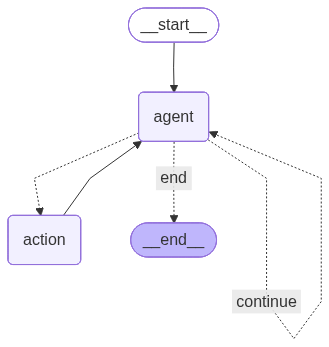

In [32]:
agent_with_helpfulness_check

##### ✅ Answer:
Pass the user query into the `inputs` variable<br>
Execute the `agent_with_helpfulness_check` graph with the given user query in an asynchronous fashion and return the output as a asynchronous stream.<br>
Process the node and value in stream, and display the node from which the update was received along with the message

In [31]:
inputs = {"messages" : [HumanMessage(content="What are Deep Research Agents?")]}

async for chunk in agent_with_helpfulness_check.astream(inputs, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values["messages"])
        print("\n\n")

Receiving update from node: 'agent'
[AIMessage(content='Deep Research Agents are advanced AI systems designed to assist with complex research tasks. They leverage deep learning techniques and large datasets to analyze, synthesize, and generate insights across various fields of study. These agents can automate literature reviews, extract relevant information from vast amounts of data, identify patterns, and even generate hypotheses or summaries to support researchers in their work. They are used in academia, industry, and scientific research to accelerate discovery and improve the accuracy and depth of research outcomes. Would you like more detailed information or specific examples?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 158, 'total_tokens': 263, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'

## Part 3: LangGraph for the "Patterns" of GenAI

### Task 4: Helpfulness Check of Gen AI Pattern Descriptions

Let's ask our system about the 3 main patterns in Generative AI:

1. Context Engineering
2. Fine-tuning
3. Agents

In [34]:
patterns = ["Context Engineering", "Fine-tuning", "LLM-based agents"]

In [35]:
for pattern in patterns:
  what_is_string = f"What is {pattern} and when did it break onto the scene??"
  inputs = {"messages" : [HumanMessage(content=what_is_string)]}
  messages = agent_with_helpfulness_check.invoke(inputs)
  print(messages["messages"][-1].content)
  print("\n\n")

Context Engineering is a relatively new interdisciplinary field that focuses on designing, managing, and utilizing contextual information to improve the functionality and adaptability of systems, particularly in areas like artificial intelligence, human-computer interaction, and pervasive computing. It involves understanding and engineering the context in which systems operate to enhance their performance, relevance, and user experience.

The concept of Context Engineering began gaining attention in the early 2000s with the rise of ubiquitous computing and context-aware systems. It became more prominent as researchers and industry professionals recognized the importance of context in creating intelligent, responsive systems that can adapt to dynamic environments and user needs.

Would you like me to find more detailed and specific information about the origins and development of Context Engineering?



Fine-tuning is a machine learning technique used to adapt a pre-trained model to a s